In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_pops = 100         # Number of populations in the ensemble
m = 10               # Number of variants per population
ngens = 500          # Number of generations
rho = 0.5            # Correlation between X and Y
mu_X, mu_Y = -0.1, -0.1
sigma_X, sigma_Y = 0.01, 0.01

cov_XY = rho * sigma_X * sigma_Y
cov_matrix = np.array([[sigma_X**2, cov_XY], [cov_XY, sigma_Y**2]])

np.random.seed(42)  # For reproducibility

print("Done!")

Done!


In [18]:
mean_fitness_ensemble = np.zeros((ngens, n_pops))
cov_ensemble = np.zeros((ngens, n_pops))

for pop in range(n_pops):
    XY = np.exp(np.random.multivariate_normal([mu_X, mu_Y], cov_matrix, size=m))
    fitnesses = XY[:,0] + XY[:,1]
    freqs = np.ones(m) / m

    mean_fitness_ensemble[0, pop] = np.sum(freqs * fitnesses)
    cov_ensemble[0, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]

    for gen in range(1, ngens):
        wbar = np.sum(freqs * fitnesses)
        freqs = freqs * fitnesses / wbar
        mean_fitness_ensemble[gen, pop] = np.sum(freqs * fitnesses)
        cov_ensemble[gen, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]

print("Done!")

Done!


In [48]:
mean_fitness_ensemble = np.zeros((ngens, n_pops))
cov_ensemble = np.zeros((ngens, n_pops))

for pop in range(n_pops):
    XY = np.random.multivariate_normal([mu_X, mu_Y], cov_matrix, size=m)
    fitnesses = XY[:,0] + XY[:,1]
    freqs = np.ones(m) / m

    mean_fitness_ensemble[0, pop] = np.sum(freqs * fitnesses)
    cov_ensemble[0, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]

    for gen in range(1, ngens):
        zz = np.sum(freqs * np.exp(fitnesses * gen))
        freq = freqs * np.exp(fitnesses * gen) / zz
        mean_fitness_ensemble[gen, pop] = np.sum(freq * fitnesses)
        cov_ensemble[gen, pop] = np.cov(XY[:,0], XY[:,1], aweights=freq)[0,1]

print("Done!")

Done!


In [42]:
freq

array([6.87836828e-09, 6.49630660e-13, 2.26883173e-06, 4.54955193e-07,
       3.76688375e-10, 5.02670559e-02, 2.21422801e-01, 3.52155511e-01,
       3.76151899e-01, 1.60654547e-09])

In [40]:
fitnesses*freqs

array([-0.01831704, -0.01891449, -0.02165086, -0.0212559 , -0.01888892,
       -0.02138635, -0.02205926, -0.02060873, -0.01995406, -0.01971756])

In [55]:
# From 0 to 9 (10 numbers)
numbers = [x / 3 for x in range(10)]
print(numbers)
# Output: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[0.0, 0.3333333333333333, 0.6666666666666666, 1.0, 1.3333333333333333, 1.6666666666666667, 2.0, 2.3333333333333335, 2.6666666666666665, 3.0]


In [ ]:
mean_fitness_ensemble = np.zeros((ngens, n_pops))
cov_ensemble = np.zeros((ngens, n_pops))

for pop in range(n_pops):
    XY = np.exp(np.random.multivariate_normal([mu_X, mu_Y], cov_matrix, size=m))
    fitnesses = XY[:,0] + XY[:,1]
    freqs = np.ones(m) / m

    mean_fitness_ensemble[0, pop] = np.sum(freqs * fitnesses)
    cov_ensemble[0, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]

    for gen in range(1, ngens):
        wbar = np.sum(freqs * fitnesses)
        freqs = freqs * fitnesses / wbar
        mean_fitness_ensemble[gen, pop] = np.sum(freqs * fitnesses)
        # cov_ensemble[gen, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]
        fq = freqs/np.sum(freqs)
        cov_ensemble[gen, pop] = np.sum(fq*(XY[:,0] - np.sum(XY[:,0]*fq))*(XY[:,1] - np.sum(XY[:,1]*fq)))

print("Done!")

Done!


In [ ]:
mean_fitness_ensemble = np.zeros((ngens, n_pops))
cov_ensemble = np.zeros((ngens, n_pops))

for pop in range(n_pops):
    XY = np.exp(np.random.multivariate_normal([mu_X, mu_Y], cov_matrix, size=m))
    fitnesses = XY[:,0] + XY[:,1]
    freqs = np.ones(m) / m

    mean_fitness_ensemble[0, pop] = np.sum(freqs * fitnesses)
    cov_ensemble[0, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]

    for gen in range(1, ngens):
        wbar = np.sum(freqs * fitnesses)
        freqs = freqs * fitnesses / wbar
        mean_fitness_ensemble[gen, pop] = np.sum(freqs * fitnesses)
        cov_ensemble[gen, pop] = np.cov(XY[:,0], XY[:,1], aweights=freqs)[0,1]

print("Done!")

Done!


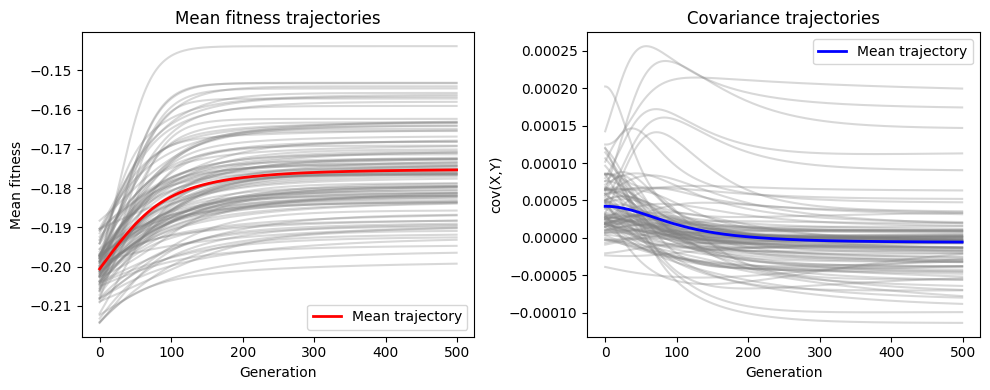

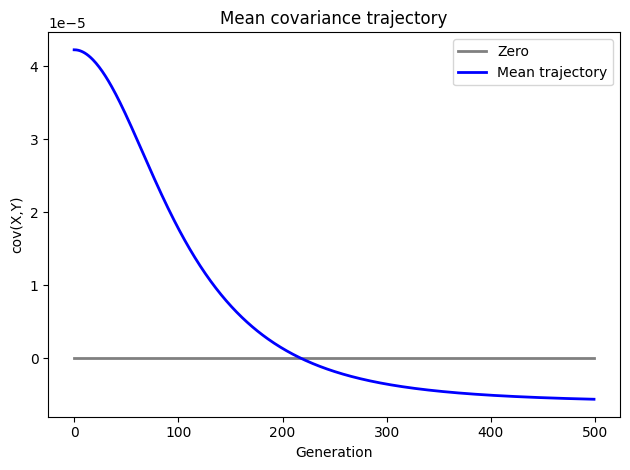

In [49]:
mean_fit_mean = np.mean(mean_fitness_ensemble, axis=1)
cov_mean = np.mean(cov_ensemble, axis=1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
for i in range(n_pops):
    plt.plot(mean_fitness_ensemble[:,i], color='gray', alpha=0.3)
plt.plot(mean_fit_mean, color='red', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('Mean fitness')
plt.title('Mean fitness trajectories')
plt.legend()

plt.subplot(1,2,2)
for i in range(n_pops):
    plt.plot(cov_ensemble[:,i], color='gray', alpha=0.3)
plt.plot(cov_mean, color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

plt.tight_layout()
plt.show()

plt.plot(np.zeros(len(cov_mean)), color='gray', lw=2, label='Zero')
plt.plot(cov_mean, color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Mean covariance trajectory')
plt.legend()

plt.tight_layout()
plt.show()

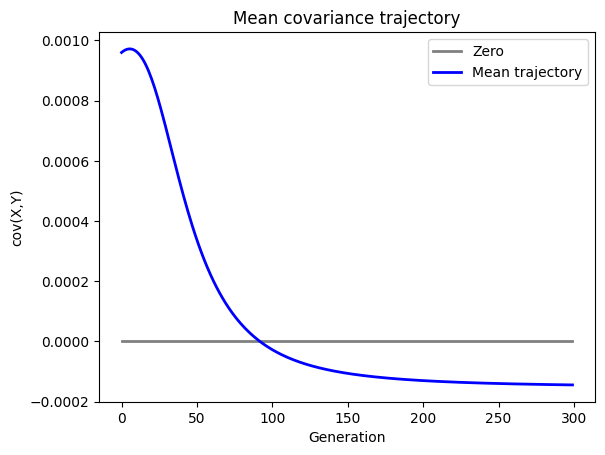

In [25]:
plt.plot(np.zeros(len(cov_mean)), color='gray', lw=2, label='Zero')
plt.plot(cov_mean, color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Mean covariance trajectory')
plt.legend()

In [52]:
ti=3
[range(1, ngens*ti)/ti]

TypeError: unsupported operand type(s) for /: 'range' and 'int'

In [73]:
import numpy as np

XY = np.array([[1, 2], [3, 4], [5, 6]])
freqs = np.array([0.1, 0.2, 0.3])
fq = freqs/np.sum(freqs)

np.cov(XY[:,0], XY[:,1], aweights=fq)[0,1]

np.float64(3.6363636363636362)

In [58]:
np.cov(XY[:,0], XY[:,1])[0,1]

np.float64(4.0)

In [66]:
np.sum(XY[:,0]*freqs)

np.float64(2.2)

In [67]:
XY[:,0]*freqs - np.sum(XY[:,0]*freqs)

array([-2.1, -1.6, -0.7])

In [70]:
fq = freqs/np.sum(freqs)

In [71]:
fq

array([0.16666667, 0.33333333, 0.5       ])

In [74]:
np.sum(fq)

np.float64(0.9999999999999999)

In [75]:
np.sum(fq*(XY[:,0] - np.sum(XY[:,0]*fq))*(XY[:,1] - np.sum(XY[:,1]*fq)))

np.float64(2.222222222222222)

In [65]:
(XY[:,0] - np.mean(XY[:,0]))*(XY[:,1] - np.mean(XY[:,1]))

array([4., 0., 4.])

In [77]:
fq[0]

np.float64(0.16666666666666666)

In [82]:
fq[0]*fq[1]*(XY[1,0] - XY[0,0])*(XY[1,1]-XY[0,1]) + fq[0]*fq[2]*(XY[2,0] - XY[0,0])*(XY[2,1]-XY[0,1]) + fq[1]*fq[2]*(XY[2,0] - XY[1,0])*(XY[2,1]-XY[1,1])

np.float64(2.222222222222222)

In [ ]:
mean_fitness_ensemble = np.zeros((ngens*ti, n_pops))
cov_ensemble = np.zeros((ngens*ti, n_pops))


for pop in range(n_pops):
    # XY = sample_bivariate(distribution_type, m)
    XY = np.random.normal(mu_X, sigma_X, size=2**m)
    fitnesses = np.exp(XY[:,0] + XY[:,1])
    if initial_freq_type == "equal":
        freqs = np.ones(m) / m
    elif initial_freq_type == "random":
        freqs = np.random.uniform(0, 1, m)
        freqs = freqs / np.sum(freqs)
    else:
        raise ValueError("Unknown initial frequency type")

    fq = freqs/np.sum(freqs)
    mean_fitness_ensemble[0, pop] = np.sum(fq * fitnesses)
    cov_ensemble[0, pop] = np.sum(fq*(XY[:,0] - np.sum(XY[:,0]*fq))*(XY[:,1] - np.sum(XY[:,1]*fq)))

    for gen in range(1, ngens * ti):
        wbar = np.sum(freqs * fitnesses)
        freqs = freqs * (fitnesses / wbar)**(1/ti)
        fq = freqs/np.sum(freqs)
        mean_fitness_ensemble[gen, pop] = np.sum(fq * fitnesses)
        cov_ensemble[gen, pop] = np.sum(fq*(XY[:,0] - np.sum(XY[:,0]*fq))*(XY[:,1] - np.sum(XY[:,1]*fq)))

print("Done!")

array([[1, 2],
       [3, 4],
       [5, 6]])

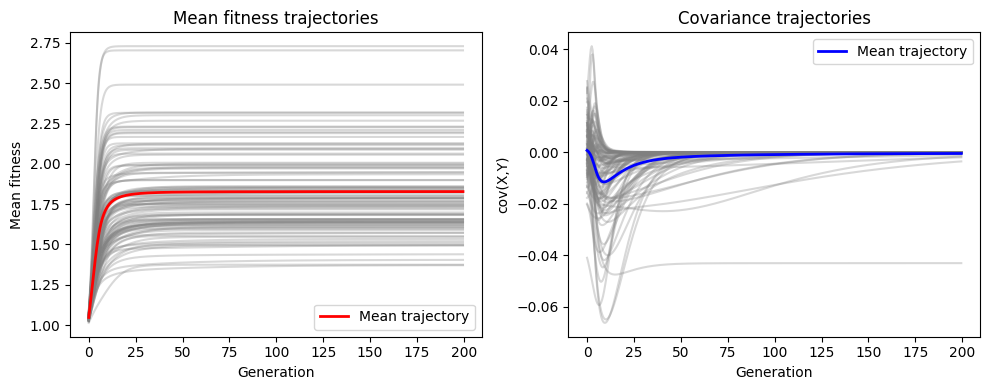

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# **********************************************************
# ***    CHOOSE BIVARIATE DISTRIBUTION                   ***
# **********************************************************
distribution_type = "multivariate_normal"  
# options: "multivariate_normal", "bivariate_t", "bivariate_uniform"

# **********************************************************
# ***    CHOOSE INITIAL FREQUENCIES SCHEME               ***
# **********************************************************
initial_freq_type = "equal"  
# options: "equal" or "random"

# **********************************************************
# ***    SIMULATION PARAMETERS                           ***
# **********************************************************
n_pops = 100           # Number of populations in the ensemble
m = 20                 # Number of distinct genotypes (individuals) per population
ngens = 5000           # Number of generations to simulate
ti = 2                 # Time increments per generation (for smoother dynamics)
rho = 0.5              # Initial correlation between X and Y loci
mu_X, mu_Y = -0.1, -0.1  # Mean values for loci X and Y
sigma_X, sigma_Y = 0.05, 0.05  # Standard deviations for loci X and Y
cov_XY = rho * sigma_X * sigma_Y  # Covariance between X and Y
cov_matrix = np.array([[sigma_X**2, cov_XY], [cov_XY, sigma_Y**2]])  # Covariance matrix for bivariate distributions
tf = 200               # Final time (in generations) for ensemble plots
tr = tf*ti             # Final time (in time increments) for ensemble plots

def sample_bivariate(dist, size):
    if dist == "multivariate_normal":
        return np.random.multivariate_normal([mu_X, mu_Y], cov_matrix, size=size)
    elif dist == "bivariate_t":
        df = 5
        g = np.random.gamma(df / 2., 2. / df, size=(size,))
        Z = np.random.multivariate_normal([0, 0], cov_matrix, size=size)
        return np.array([mu_X, mu_Y]) + Z / np.sqrt(g)[:, None]
    elif dist == "bivariate_uniform":
        low  = [mu_X - sigma_X * np.sqrt(3), mu_Y - sigma_Y * np.sqrt(3)]
        high = [mu_X + sigma_X * np.sqrt(3), mu_Y + sigma_Y * np.sqrt(3)]
        return np.random.uniform(low, high, size=(size,))
    else:
        raise ValueError("Unknown distribution type")


np.random.seed(42)  # For reproducibility


mean_fitness_ensemble = np.zeros((ngens * ti, n_pops))
cov_ensemble = np.zeros((ngens * ti, n_pops))
sex_potential_ensemble = np.zeros((ngens * ti, n_pops))

for pop in range(n_pops):
    # Step 1: Generate epistatic fitness matrix W (m x m)
    W = np.random.normal(loc=0.0, scale=1.0, size=(m, m))

    # Step 2: Extract additive components X and Y via row/col means
    overall_mean = np.mean(W)
    X = np.mean(W, axis=1) - overall_mean  # shape (m,)
    Y = np.mean(W, axis=0) - overall_mean  # shape (m,)

    # Step 3: Use only diagonal fitnesses (non-recombinant genotypes)
    fitnesses = np.exp(np.diag(X[:, None] + Y[None, :]))  # shape (m,)

    # Initial frequencies over non-recombinants
    if initial_freq_type == "equal":
        freqs = np.ones(m) / m
    elif initial_freq_type == "random":
        freqs = np.random.uniform(0, 1, m)
        freqs = freqs / np.sum(freqs)
    else:
        raise ValueError("Unknown initial frequency type")

    fq = freqs / np.sum(freqs)
    mean_fitness_ensemble[0, pop] = np.sum(fq * fitnesses)
    
    # Step 2: Extract additive components X and Y via row/col means
    overall_mean = W*fq
    X = np.mean(W, axis=1) - overall_mean  # shape (m,)
    Y = np.mean(W, axis=0) - overall_mean  # shape (m,)

    # Weighted covariance from original code
    xbar = np.sum(X * fq)
    ybar = np.sum(Y * fq)
    cov = np.sum(fq * (X - xbar) * (Y - ybar))
    cov_ensemble[0, pop] = cov

    # Sex potential: compare mean fitness of recombinants vs non-recombinants
    recomb_mask = ~np.eye(m, dtype=bool)
    recomb_fitnesses = np.exp(X[:, None] + Y[None, :])[recomb_mask]
    sex_potential = np.mean(recomb_fitnesses) - np.mean(fitnesses)
    sex_potential_ensemble[0, pop] = sex_potential

    for gen in range(1, ngens * ti):
        wbar = np.sum(freqs * fitnesses)
        freqs = freqs * (fitnesses / wbar)**(1/ti)
        fq = freqs / np.sum(freqs)
        mean_fitness_ensemble[gen, pop] = np.sum(fq * fitnesses)

        xbar = np.sum(X * fq)
        ybar = np.sum(Y * fq)
        cov = np.sum(fq * (X - xbar) * (Y - ybar))
        cov_ensemble[gen, pop] = cov

        sex_potential = np.mean(recomb_fitnesses) - np.sum(fq * fitnesses)
        sex_potential_ensemble[gen, pop] = sex_potential

mean_sex_potential = np.mean(sex_potential_ensemble, axis=1)
mean_fit_mean = np.mean(mean_fitness_ensemble, axis=1)
cov_mean = np.mean(cov_ensemble, axis=1)

#| caption: "Trajectory-ensemble plots"

plt.figure(figsize=(10,4))

xx = [x / ti for x in range(ngens*ti)]

plt.subplot(1,2,1)
for i in range(n_pops):
    plt.plot(xx[:tr], mean_fitness_ensemble[:tr,i], color='gray', alpha=0.3)
plt.plot(xx[:tr], mean_fit_mean[:tr], color='red', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('Mean fitness')
plt.title('Mean fitness trajectories')
plt.legend()

plt.subplot(1,2,2)
for i in range(n_pops):
    plt.plot(xx[:tr], cov_ensemble[:tr,i], color='gray', alpha=0.3)
plt.plot(xx[:tr], cov_mean[:tr], color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
del fqs

In [340]:
import numpy as np
from scipy.optimize import least_squares

# Parameters
m = 5  # number of genotypes (i = 0 to m-1)
ngens = 200
ti = 1
n_pops = 100

# Fitness matrix: full m x m matrix of w_ij drawn from univariate distribution
W = np.random.normal(loc= -0.2, scale=0.1, size=(n_pops, m, m))
# for p in range(n_pops):
#     W[p] = (W[p] + W[p].T) / 2  # make symmetric if needed

# Arrays to store results
sex_potential_ensemble = np.zeros((ngens*ti, n_pops))
mean_fitness_ensemble = np.zeros((ngens*ti, n_pops))
cov_ensemble = np.zeros((ngens*ti, n_pops))

fqs = np.zeros((ngens*ti, n_pops, m))

wws = np.zeros((ngens*ti, n_pops, m, m))

for pop in range(n_pops):
    # Initial frequencies for diagonal genotypes only
    freqs = np.ones(m) / m
    freqs = freqs / np.sum(freqs)
    
    fq = freqs
    rfq = np.outer(fq, fq)

    # Initial fitnesses are diagonal of W
    fit = np.diag(W[pop])
    rfit = W[pop]
    mean_fitness_ensemble[0, pop] = np.sum(fq * fit)

    # Initial additive decomposition
    def loss(add_vec):
        X = add_vec[:m]
        Y = add_vec[m:]
        X_plus_Y = X[:, None] + Y[None, :]
        rfq = np.outer(fq, fq)
        return (rfq * (X_plus_Y - W[pop])**2).ravel()

    add_init = np.random.normal(size=2 * m)
    res = least_squares(loss, add_init)
    X, Y = res.x[:m], res.x[m:]

    X_mean = np.sum(fq * X)
    Y_mean = np.sum(fq * Y)
    cov_ensemble[0, pop] = np.sum(fq * (X - X_mean) * (Y - Y_mean))
    
    fqs[0, pop, :] = fq
    
    ww = X[:, None] + Y[None, :]
    wws[0, pop, :, :] = ww
    
    # fit = np.exp(X_mean + Y_mean)
    # rfit = np.exp(X[:, None] + Y[None, :])
    rfq = np.outer(fq, fq)
    # sr = ti * (np.sum(rfq * rfit * np.exp(rfit))/np.sum(rfq * np.exp(rfit))) - (np.sum(fq * fit * np.exp(fit))/np.sum(fq * np.exp(fit)))
    # sr = (np.sum(rfq * rfit * np.exp(rfit)) - np.sum(rfq * np.exp(rfit))) - (np.sum(fq * fit * np.exp(fit)) - np.sum(fq * np.exp(fit)))
    # sr = np.sum(rfq * rfit * np.exp(rfit)) - np.sum(fq * fit * np.exp(fit))
    sr = np.sum(rfq * np.exp(rfit)) - np.sum(fq * np.exp(fit))
    
    sex_potential_ensemble[0, pop] = sr

    for gen in range(1, ngens * ti):
        
        fit = np.diag(W[pop])
        rfit = W[pop]
        
        wbar = np.sum(fq * np.exp(fit))
        fq = fq * (np.exp(fit) / wbar) ** (1/ti)
        fq = fq / np.sum(fq)

        # Update fitnesses
        mean_fitness_ensemble[gen, pop] = np.sum(fit * fq)

        # Recompute additive decomposition
        def loss(add_vec):
            X = add_vec[:m]
            Y = add_vec[m:]
            ww = X[:, None] + Y[None, :]
            rfq = np.outer(fq, fq)
            return (rfq * (ww - W[pop])**2).ravel()

        res = least_squares(loss, add_init)
        X, Y = res.x[:m], res.x[m:]

        X_mean = np.sum(fq * X)
        Y_mean = np.sum(fq * Y)
        cov_ensemble[gen, pop] = np.sum(fq * (X - X_mean) * (Y - Y_mean))
        
        # fit = np.exp(X_mean + Y_mean)
        # rfit = np.exp(X[:, None] + Y[None, :])
        rfq = np.outer(fq, fq)
        # sr = ti * (np.sum(rfq * rfit * np.exp(rfit))/np.sum(rfq * np.exp(rfit))) - (np.sum(fq * fit * np.exp(fit))/np.sum(fq * np.exp(fit)))
        # sr = (np.sum(rfq * rfit * np.exp(rfit)) - np.sum(rfq * np.exp(rfit))) - (np.sum(fq * fit * np.exp(fit)) - np.sum(fq * np.exp(fit)))
        # sr = np.sum(rfq * rfit * np.exp(rfit)) - np.sum(fq * fit * np.exp(fit))
        sr = np.sum(rfq * np.exp(rfit)) - np.sum(fq * np.exp(fit))
        
        sex_potential_ensemble[gen, pop] = sr
        fqs[gen, pop, :] = fq
        wws[gen, pop, :, :] = rfit

# Output preview
mean_fitness_ensemble, cov_ensemble


(array([[-0.09341087, -0.15714585, -0.17334116, ..., -0.19651246,
         -0.15960349, -0.17116432],
        [-0.09131595, -0.15232847, -0.160028  , ..., -0.19431444,
         -0.15791413, -0.16103081],
        [-0.08923552, -0.14738991, -0.14589501, ..., -0.19203276,
         -0.15621436, -0.15082819],
        ...,
        [-0.0305121 , -0.04539416,  0.02491704, ..., -0.1136013 ,
         -0.1107272 , -0.02413705],
        [-0.03051111, -0.04539416,  0.02491704, ..., -0.11360129,
         -0.11072572, -0.02413704],
        [-0.03051015, -0.04539416,  0.02491704, ..., -0.11360128,
         -0.11072424, -0.02413703]], shape=(200, 100)),
 array([[ 1.93801755e-04,  3.91385608e-04,  5.53792235e-04, ...,
         -8.05622195e-05, -2.20759504e-04,  2.29109462e-04],
        [ 1.52235485e-04,  6.42364756e-04,  3.87769656e-04, ...,
         -1.91326926e-04, -2.04335268e-04,  3.98405710e-04],
        [ 1.14101085e-04,  8.67275838e-04,  2.87495454e-04, ...,
         -3.14819050e-04, -1.81955778e

In [220]:
np.sum(rfq * rfit * np.exp(rfit))

np.float64(-0.10861621050236914)

In [180]:
ww = X[:, None] + Y[None, :]
ww

array([[0.86486978, 0.88159381, 0.83505404, 0.88812257, 1.09477864],
       [0.98502589, 1.00174992, 0.95521015, 1.00827868, 1.21493475],
       [1.0610081 , 1.07773213, 1.03119236, 1.08426089, 1.29091695],
       [1.06875448, 1.08547851, 1.03893874, 1.09200727, 1.29866334],
       [0.85593387, 0.8726579 , 0.82611813, 0.87918666, 1.08584272]])

In [181]:
W[n_pops-1]

array([[0.98598073, 0.8170541 , 0.86141375, 1.21275951, 0.91036681],
       [0.45227226, 0.96672631, 1.28279677, 1.0719282 , 1.18472074],
       [0.87782041, 1.12736565, 0.90833617, 1.06387554, 1.23446243],
       [0.78502108, 0.64055802, 0.91581571, 1.06583631, 1.32943891],
       [1.01752403, 1.12530479, 0.86276609, 0.86836534, 1.069319  ]])

In [173]:
np.diag(ww)

array([ 0.86108918,  0.77483983, -0.18207794, -2.18919254,  1.17871051])

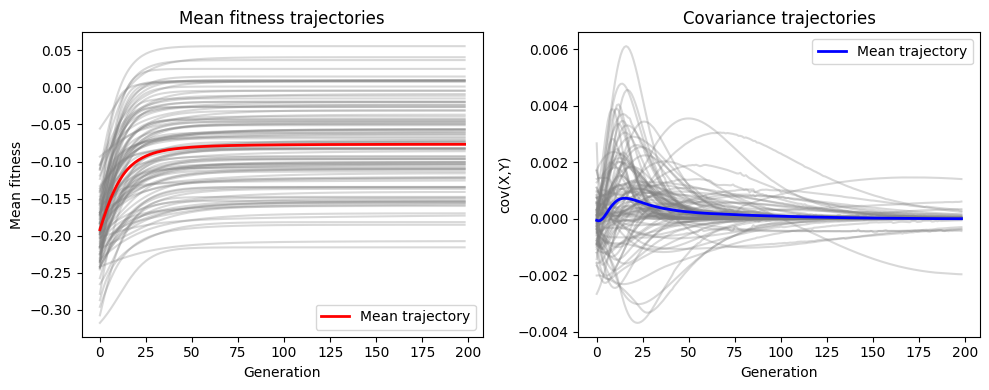

In [374]:
mean_fit_mean = np.mean(mean_fitness_ensemble, axis=1)
cov_mean = np.mean(cov_ensemble, axis=1)
mean_sex_potential = np.mean(sex_potential_ensemble, axis=1)


#| caption: "Trajectory-ensemble plots"

plt.figure(figsize=(10,4))

xx = [x / ti for x in range(ngens*ti)]

plt.subplot(1,2,1)
for i in range(n_pops):
    plt.plot(xx[:tr], mean_fitness_ensemble[:tr,i], color='gray', alpha=0.3)
plt.plot(xx[:tr], mean_fit_mean[:tr], color='red', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('Mean fitness')
plt.title('Mean fitness trajectories')
plt.legend()

plt.subplot(1,2,2)
for i in range(n_pops):
    plt.plot(xx[:tr], cov_ensemble[:tr,i], color='gray', alpha=0.3)
plt.plot(xx[:tr], cov_mean[:tr], color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

plt.tight_layout()
plt.show()

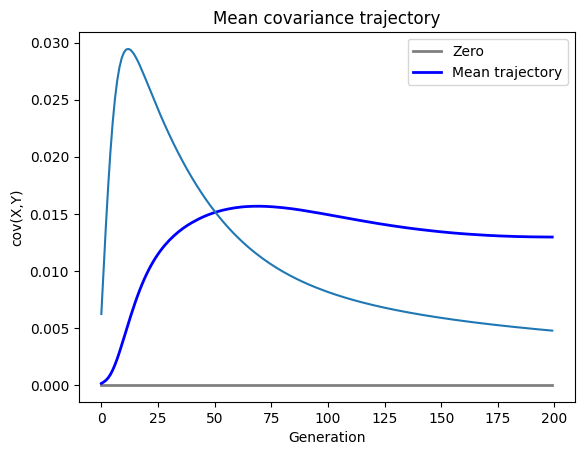

In [232]:
plt.plot(np.zeros(len(cov_mean)), color='gray', lw=2, label='Zero')
plt.plot(np.cumsum(cov_mean), color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Mean covariance trajectory')
plt.legend()
plt.plot(-mean_sex_potential)

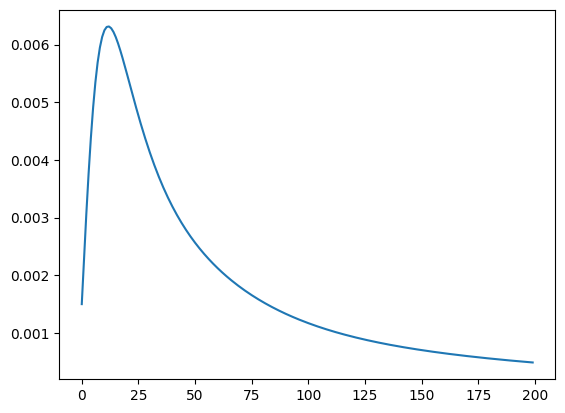

In [224]:
plt.plot(mean_sex_potential)

In [219]:
mean_sex_potential

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [160]:
wws[5,5]

array([[0.88140268, 0.95418583, 1.22163368, 1.06810518, 0.99314451],
       [0.79064871, 0.86343187, 1.13087971, 0.97735122, 0.90239055],
       [0.94366031, 1.01644347, 1.28389131, 1.13036282, 1.05540215],
       [0.85632887, 0.92911203, 1.19655987, 1.04303138, 0.96807071],
       [0.91559721, 0.98838037, 1.25582821, 1.10229971, 1.02733905]])

In [285]:
W[5]

array([[-0.18803163, -0.20002636, -0.17896207, -0.12732039, -0.07903981],
       [-0.37303877, -0.13250795, -0.23291567, -0.28689019, -0.28253382],
       [-0.03925892, -0.19413304, -0.22908544, -0.35127076, -0.25393004],
       [-0.0703421 , -0.30511706, -0.20999002, -0.24294591, -0.1792969 ],
       [-0.24092883, -0.26456283, -0.16400513, -0.24588593, -0.04709438]])

In [274]:
sr = [[(np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * wws[i,j] * np.exp(wws[i,j])) - np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * np.exp(wws[i,j]))) - (np.sum(fqs[i,j,:] * wws[i,j] * np.exp(np.diag(wws[i,j]))) - np.sum(fqs[i,j,:] * np.exp(np.diag(wws[i,j])))) for i in range(ngens*ti-1)] for j in range(n_pops-1)]

In [282]:
sr = [[(np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * wws[i,j] * np.exp(wws[i,j])) / np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * np.exp(wws[i,j]))) - (np.sum(fqs[i,j,:] * wws[i,j] * np.exp(np.diag(wws[i,j]))) / np.sum(fqs[i,j,:] * np.exp(np.diag(wws[i,j])))) for i in range(ngens*ti-1)] for j in range(n_pops-1)]
sr

[[np.float64(0.8628321746106958),
  np.float64(0.8860360721870456),
  np.float64(0.8869203490307674),
  np.float64(0.8877194270106008),
  np.float64(0.8884440438396681),
  np.float64(0.8891049547306614),
  np.float64(0.8897128073124257),
  np.float64(0.8902780307788294),
  np.float64(0.8908107394428026),
  np.float64(0.8913206504613047),
  np.float64(0.8918170151817685),
  np.float64(0.8923085633314166),
  np.float64(0.8928034591183736),
  np.float64(0.8933092682263266),
  np.float64(0.8938329346504427),
  np.float64(0.8943807663294233),
  np.float64(0.8949584285658345),
  np.float64(0.8955709442845402),
  np.float64(0.8962227002489656),
  np.float64(0.8969174584304591),
  np.float64(0.8976583718022713),
  np.float64(0.8984480039029147),
  np.float64(0.8992883515816734),
  np.float64(0.9001808704003222),
  np.float64(0.9011265022192272),
  np.float64(0.9021257045429323),
  np.float64(0.9031784812406304),
  np.float64(0.9042844142912976),
  np.float64(0.9054426962327002),
  np.float64(0

In [388]:
sr = [[(np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * W[j]**2 * np.exp(W[j])) / np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * np.exp(W[j]))) - (np.sum(fqs[i,j,:] * np.diag(W[j])**2 * np.exp(np.diag(W[j]))) / np.sum(fqs[i,j,:] * np.exp(np.diag(W[j])))) for i in range(ngens*ti-1)] for j in range(n_pops-1)]
sr

[[np.float64(0.02623171370208508),
  np.float64(0.027050094841046275),
  np.float64(0.02783099468836392),
  np.float64(0.02857122437488451),
  np.float64(0.029267872771703132),
  np.float64(0.02991832799765219),
  np.float64(0.030520294628926165),
  np.float64(0.031071806644095843),
  np.float64(0.03157123617502579),
  np.float64(0.032017298162220494),
  np.float64(0.03240905103862549),
  np.float64(0.03274589359403215),
  np.float64(0.033027558205850883),
  np.float64(0.03325410066160313),
  np.float64(0.0334258868424142),
  np.float64(0.03354357658196165),
  np.float64(0.03360810505788578),
  np.float64(0.03362066210874001),
  np.float64(0.0335826698958598),
  np.float64(0.033495759343777985),
  np.float64(0.03336174579390363),
  np.float64(0.03318260429418678),
  np.float64(0.03296044492351592),
  np.float64(0.032697488515519006),
  np.float64(0.032396043104635466),
  np.float64(0.03205848137037855),
  np.float64(0.03168721930615973),
  np.float64(0.03128469628922137),
  np.float64(

In [ ]:
sr = [[(np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * (W[i] - W[j])^2 * np.exp(t * (W[i]+W[j]))) / np.sum(np.outer(fqs[i,j,:],fqs[i,j,:]) * np.exp(W[j]))) - (np.sum(fqs[i,j,:] * np.diag(W[j]) * np.exp(np.diag(W[j]))) / np.sum(fqs[i,j,:] * np.exp(np.diag(W[j])))) for i in range(ngens*ti-1)] for j in range(n_pops-1)]
sr

array([[-0.29516046, -0.25468054, -0.13066792, -0.1854882 , -0.31806835],
       [-0.10821331, -0.22060849, -0.09694328, -0.30443825, -0.19201083],
       [-0.14823486, -0.20438555, -0.35705124, -0.14506564, -0.08437616],
       [-0.23072932, -0.19710732, -0.1149842 , -0.14416929, -0.1523321 ],
       [-0.32472145, -0.12585135, -0.06057933, -0.27523771, -0.13060032]])

In [281]:
np.diag(wws[3,3])

array([-0.29516046, -0.22060849, -0.35705124, -0.14416929, -0.13060032])

In [393]:
np.array([[1,2],[3,4]])**2

array([[ 1,  4],
       [ 9, 16]])

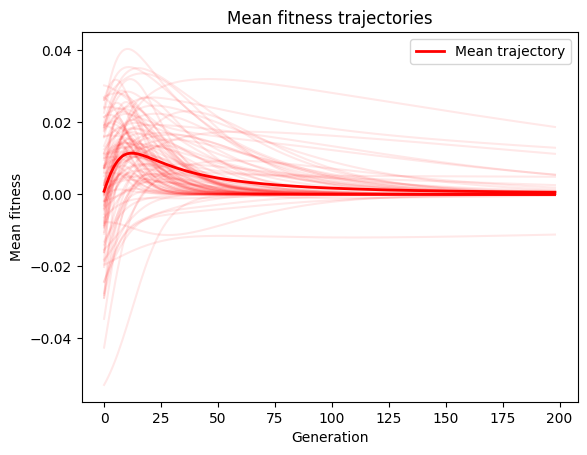

In [390]:
xx = [x / ti for x in range(ngens*ti-1)]

for i in range(n_pops-1):
    plt.plot(xx, sr[i], color='red', alpha=0.09)
plt.plot(xx, np.mean(sr, axis=0), color='red', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('Mean fitness')
plt.title('Mean fitness trajectories')
plt.legend()

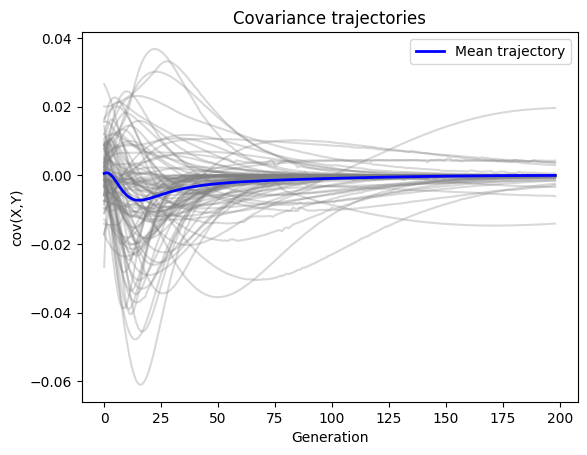

In [394]:
tr=199
for i in range(n_pops):
    plt.plot(xx[:tr], -10*cov_ensemble[:tr,i], color='gray', alpha=0.3)
plt.plot(xx[:tr], -10*cov_mean[:tr], color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

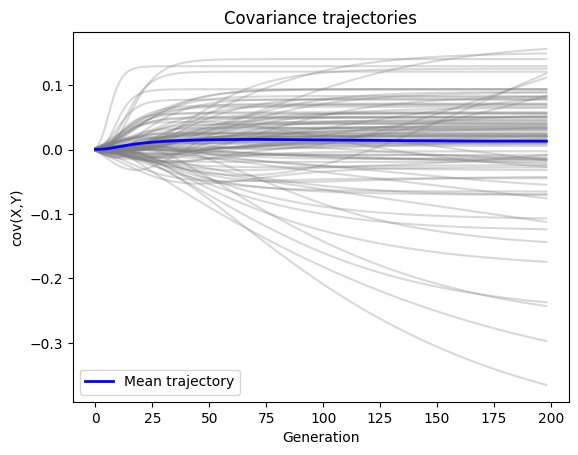

In [284]:
tr=199
for i in range(n_pops):
    plt.plot(xx[:tr], np.cumsum(cov_ensemble[:tr,i]), color='gray', alpha=0.3)
plt.plot(xx[:tr], np.cumsum(cov_mean[:tr]), color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

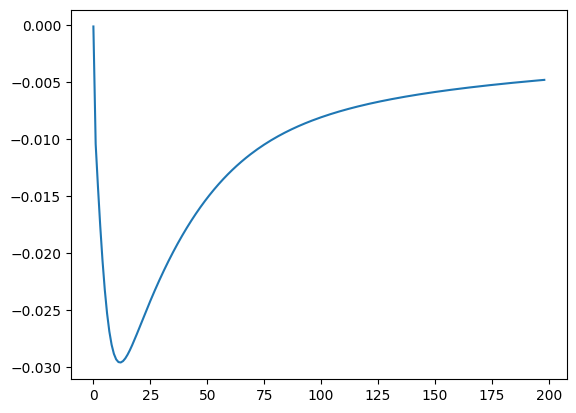

In [241]:
plt.plot(np.mean(sr, axis=0))

In [166]:
fqs[3,3,:]

array([0.12423529, 0.26366178, 0.02648581, 0.53362133, 0.05199579])

In [168]:
np.sum(fqs[3,3,:])

np.float64(1.0)

In [165]:
wws[3,3]

array([[0.93123432, 0.67316496, 0.95391493, 1.19158137, 0.73354078],
       [1.00365887, 0.7455895 , 1.02633948, 1.26400591, 0.80596533],
       [0.91131125, 0.65324189, 0.93399186, 1.1716583 , 0.71361771],
       [1.0078368 , 0.74976744, 1.03051741, 1.26818385, 0.81014326],
       [1.0582467 , 0.80017734, 1.08092732, 1.31859375, 0.86055316]])

In [162]:
np.array(sr).shape

(99, 49)

In [163]:
np.mean(sr)

np.float64(1.5402599372762943e-17)

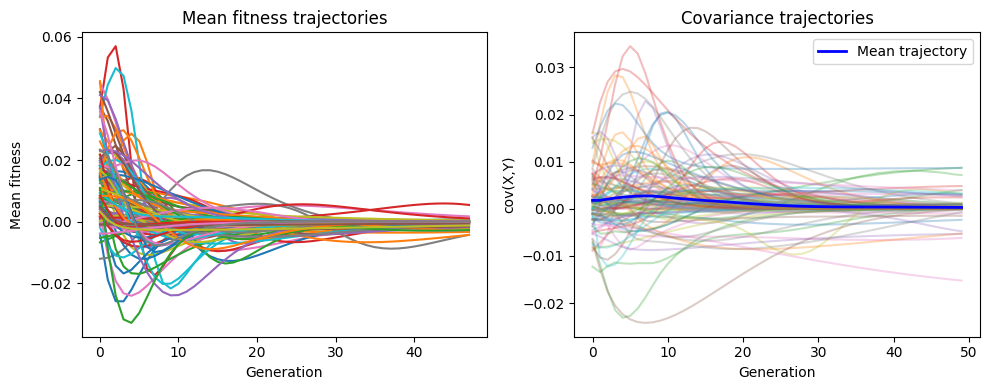

In [150]:
plt.figure(figsize=(10,4))

xx = [x / ti for x in range(ngens*ti)]

plt.subplot(1,2,1)
for i in range(n_pops-1):
    plt.plot(-1 * np.diff(np.array(sr[i])))
plt.xlabel('Generation')
plt.ylabel('Mean fitness')
plt.title('Mean fitness trajectories')

plt.subplot(1,2,2)
for i in range(n_pops):
    plt.plot(cov_ensemble[:,i], alpha=0.3)
plt.plot(cov_mean, color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

plt.tight_layout()
plt.show()

In [120]:
mean_sr = np.mean(sr, axis=0)
mean_sr

array([-0.00868565, -0.02110513, -0.03132781, -0.03931864, -0.0451547 ,
       -0.04900325, -0.0511581 , -0.05200648, -0.05193745, -0.05127415,
       -0.05025113, -0.04902017, -0.04767021, -0.04625065, -0.04479086,
       -0.04331277, -0.04183678, -0.04038291, -0.0389696 , -0.0376119 ,
       -0.03632022, -0.03510009, -0.03395262, -0.03287552, -0.0318641 ,
       -0.03091231, -0.03001348, -0.02916094, -0.02834845, -0.02757051,
       -0.02682255, -0.02610105, -0.02540351, -0.02472844, -0.02407518,
       -0.02344367, -0.02283431, -0.02224766, -0.02168431, -0.0211447 ,
       -0.02062905, -0.02013722, -0.01966877, -0.0192229 , -0.01879853,
       -0.01839427, -0.01800851, -0.01763946, -0.01728522])

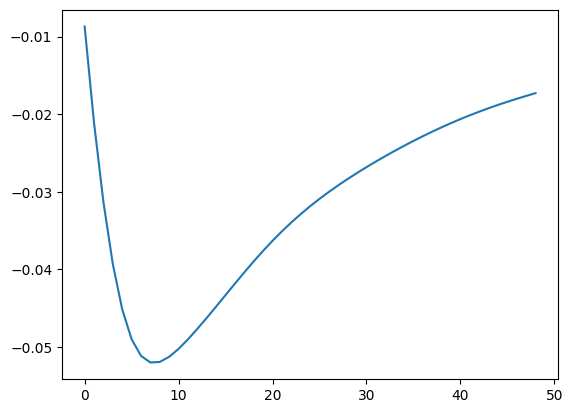

In [121]:
plt.plot(mean_sr)

In [69]:
np.sum(np.diag(fq*W[3]))

np.float64(0.9862119292045362)

In [29]:
fq_col = fq.reshape(-1, 1)
fq_col

array([[9.99999270e-01],
       [5.50985142e-10],
       [6.41537823e-09],
       [1.47414566e-10],
       [7.23162681e-07]])

In [30]:
fq_row = fq.reshape(1, -1)
fq_row

array([[9.99999270e-01, 5.50985142e-10, 6.41537823e-09, 1.47414566e-10,
        7.23162681e-07]])

In [31]:
fq_col @ fq_row

array([[9.99998539e-01, 5.50984740e-10, 6.41537354e-09, 1.47414458e-10,
        7.23162153e-07],
       [5.50984740e-10, 3.03584627e-19, 3.53477808e-18, 8.12232356e-20,
        3.98451893e-16],
       [6.41537354e-09, 3.53477808e-18, 4.11570778e-17, 9.45720197e-19,
        4.63936212e-15],
       [1.47414458e-10, 8.12232356e-20, 9.45720197e-19, 2.17310543e-20,
        1.06604713e-16],
       [7.23162153e-07, 3.98451893e-16, 4.63936212e-15, 1.06604713e-16,
        5.22964264e-13]])

In [39]:
W[2]

array([[0.69120374, 0.97510079, 1.23055018, 0.68817945, 0.91299684],
       [0.99995406, 1.21348872, 1.10893785, 1.14980696, 1.120492  ],
       [0.9253737 , 1.32868143, 0.86581816, 0.44431786, 0.63989179],
       [0.97662182, 0.93369105, 0.8927271 , 1.03004088, 1.24008559],
       [1.09080563, 1.12971004, 0.78404248, 0.89611016, 1.14007115]])

In [ ]:
import numpy as np

def matrix_case_log_expression(fy, y, s):
    """
    fy : numpy array of shape (n,)
    y  : numpy array of shape (n,)
    s  : scalar
    
    Returns:
        scalar value of the log expression
    """
    n = fy.shape[0]
    one_n = np.ones(n)
    
    # Construct the matrix (y 1^T + 1 y^T), shape (n,n)
    Y_matrix = np.outer(y, one_n) + np.outer(one_n, y)
    
    # Compute the elementwise exponential matrix
    exp_matrix = np.exp((s / 2) * Y_matrix)
    
    # Compute fy^T @ exp_matrix @ fy
    val = fy.T @ exp_matrix @ fy
    
    # Return log( (1/n^2) * val )
    return np.log(val / (n**2))

def vector_case_tilde_y(Y):
    """
    Y : numpy array of shape (n, d), each y_i is a d-dimensional vector
    
    Returns:
        numpy array of shape (n,), the vector \tilde{y} = Y 1_d
    """
    d = Y.shape[1]
    one_d = np.ones(d)
    
    # Matrix-vector product Y @ 1_d
    tilde_y = Y @ one_d
    
    return tilde_y

# Example usage:

# Matrix case
n = 4
fy = np.array([1.0, 2.0, 1.0, 3.0])
y = np.array([0.5, -0.1, 0.3, 0.7])
s = 1.5

result_matrix_case = matrix_case_log_expression(fy, y, s)
print("Matrix case result:", result_matrix_case)

# Vector case
n, d = 4, 3
Y = np.array([[0.5, 0.2, 0.1],
              [-0.1, 0.0, 0.3],
              [0.3, -0.2, 0.4],
              [0.7, 0.1, -0.1]])

result_vector_case = vector_case_tilde_y(Y)
print("Vector case \\tilde{y}:", result_vector_case)


In [352]:
import numpy as np

def w_recomb(fy, Y, s):
    """
    fy : (n,) frequency vector
    Y  : (n,n) matrix
    s  : scalar
    
    Returns:
        L : log of weighted mean of exp(sY)
        L_prime : first derivative w.r.t s
        L_double_prime : second derivative w.r.t s
    """
    n = fy.shape[0]
    
    F = np.outer(fy, fy)       # Frequency matrix
    
    E = np.exp(s * Y)          # exp(s * Y), elementwise
    
    S0 = np.sum(F * E)         # sum f_i f_j exp(s y_ij)
    S1 = np.sum(F * Y * E)     # sum f_i f_j y_ij exp(s y_ij)
    S2 = np.sum(F * (Y**2) * E) # sum f_i f_j y_ij^2 exp(s y_ij)
    
    L = np.log(S0 / (n**2))
    
    L_prime = S1 / S0
    
    L_double_prime = (S2 * S0 - S1**2) / (S0**2)
    
    return L, L_prime, L_double_prime

# Example usage:
n = 4
fy = np.array([0.1, 0.2, 0.3, 0.4])
Y = np.array([[0.5, -0.2, 0.3, 0.1],
              [-0.1, 0.0, 0.4, 0.2],
              [0.3, -0.2, 0.1, 0.0],
              [0.7, 0.1, -0.1, 0.3]])
s = 0.0

L, L_prime, L_double_prime = w_recomb(fy, Y, s)
print("L(s) =", L)
print("L'(s) =", L_prime)
print("L''(s) =", L_double_prime)


L(s) = -2.772588722239781
L'(s) = 0.13
L''(s) = 0.0445


In [351]:
import numpy as np

def wo_recomb(fy, Y, s):
    """
    fy : (n,) frequency vector
    Y  : (n,n) matrix
    s  : scalar
    
    Returns:
        L : log of weighted mean of exp(s diag(Y))
        L_prime : first derivative w.r.t s
        L_double_prime : second derivative w.r.t s
    """
    y_diag = np.diag(Y)
    f2 = fy
    
    E = np.exp(s * y_diag)
    
    S0 = np.sum(f2 * E)
    S1 = np.sum(f2 * y_diag * E)
    S2 = np.sum(f2 * y_diag**2 * E)
    
    L = np.log(S0)
    L_prime = S1 / S0
    L_double_prime = (S2 * S0 - S1**2) / S0**2
    
    return L, L_prime, L_double_prime

# Example usage
n = 4
fy = np.array([0.1, 0.2, 0.3, 0.4])
Y = np.array([[0.5, -0.2, 0.3, 0.1],
              [-0.1, 0.0, 0.4, 0.2],
              [0.3, -0.2, 0.1, 0.0],
              [0.7, 0.1, -0.1, 0.3]])
s = 0.0

L_vec, Lp_vec, Lpp_vec = wo_recomb(fy, Y, s)
print("Vector case:")
print("L(s) =", L_vec)
print("L'(s) =", Lp_vec)
print("L''(s) =", Lpp_vec)


Vector case:
L(s) = 0.0
L'(s) = 0.2
L''(s) = 0.023999999999999994


In [308]:
rm = np.random.uniform(0,1,size=5)
rm = rm/np.sum(rm)
rm

array([0.09741886, 0.38106858, 0.13741209, 0.30441672, 0.07968375])

In [311]:
ra = np.random.normal(size=(5,5))/20
ra

array([[-1.29398375e-02,  1.18048799e-02,  1.80441962e-03,
        -2.69022424e-02,  6.37672620e-02],
       [-4.75387203e-02,  1.18586106e-01, -3.28187313e-02,
        -2.85646703e-02, -3.91082407e-03],
       [-3.47198397e-05, -3.90746869e-02, -7.51423948e-03,
         1.12783454e-02,  3.96082676e-02],
       [-5.01103460e-02, -1.28085519e-01, -8.10651290e-02,
        -2.33202732e-02, -4.53529788e-02],
       [-5.81078955e-03, -5.37648900e-02, -3.61386595e-03,
         3.78938118e-02, -2.38276114e-03]])

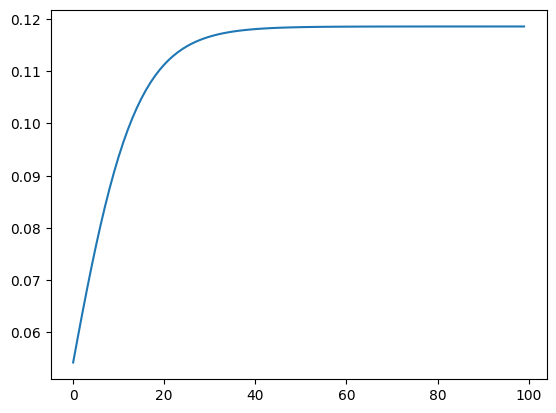

In [321]:
plt.plot([wo_recomb(rm,ra,i)[1] for i in range(100)])

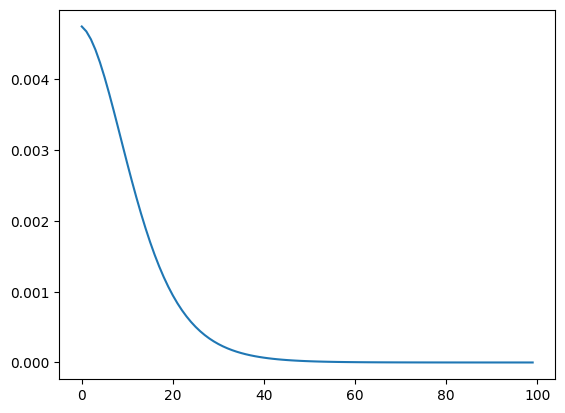

In [322]:
plt.plot([wo_recomb(rm,ra,i)[2] for i in range(100)])

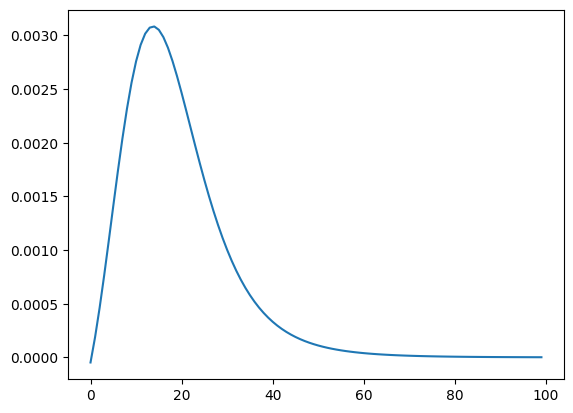

In [323]:
plt.plot([w_recomb(rm,ra,i)[2] - wo_recomb(rm,ra,i)[2] for i in range(100)])

In [327]:
np.shape(W[1])[1]

5

In [328]:
np.ones(5)/5

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [330]:
len(W)

100

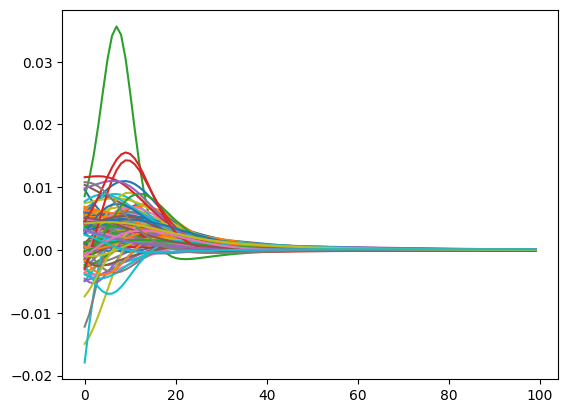

In [353]:
od = 2
for i in range(len(W)):
    k1 = i
    n1 = np.shape(W[k1])[1]
    fq = np.ones(n1)/n1
    plt.plot([w_recomb(fq,W[k1],i)[od] - wo_recomb(fq,W[k1],i)[od] for i in range(100)])

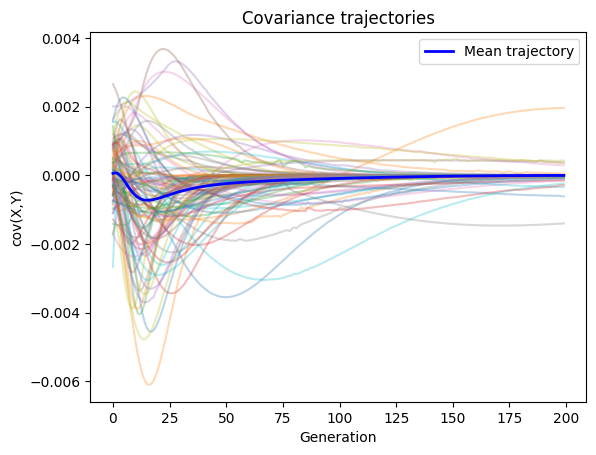

In [402]:
for i in range(n_pops):
    plt.plot(-cov_ensemble[:,i], alpha=0.3)
plt.plot(-cov_mean, color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()

In [362]:
w_recomb(rm,ra,0)

(np.float64(-3.2188758248682006),
 np.float64(-0.014751405895080809),
 np.float64(0.004699084232879264))

In [398]:
od = 1
a1 = []
for i in range(n_pops):
    a2 = []
    for j in range(ngens):
        fq = fqs[j,i]
        # fq = np.ones(m)/m
        # ww = wws[j,i]
        ww = W[i]
        dx = w_recomb(fq,ww,0)[od] - wo_recomb(fq,ww,0)[od]
        a2.append(dx)
    a1.append(a2)

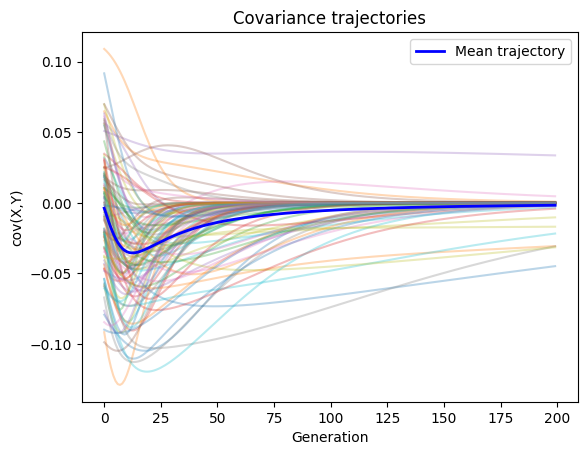

In [400]:
for i in range(len(a1)):
    plt.plot(a1[i], alpha=0.3)
plt.plot(np.mean(a1,axis=0), color='blue', lw=2, label='Mean trajectory')
plt.xlabel('Generation')
plt.ylabel('cov(X,Y)')
plt.title('Covariance trajectories')
plt.legend()
plt.show()

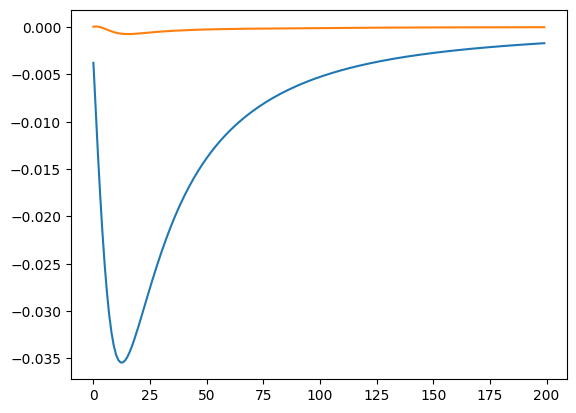

In [401]:
plt.plot(np.mean(a1, axis=0))
plt.plot(-cov_mean)

In [386]:
W[7]

array([[-0.30852476, -0.1417721 , -0.02327189, -0.25583002, -0.26988942],
       [-0.24258963, -0.15031249, -0.20250872, -0.10949022, -0.18151543],
       [-0.25068188, -0.15248325, -0.19585857, -0.37098881, -0.46301599],
       [-0.22766711, -0.22865507, -0.05066407, -0.26527425, -0.34175519],
       [-0.07036586, -0.17726042, -0.23745074, -0.21624748, -0.18412269]])

In [395]:
import numpy as np

def variance_difference(fy, y, fx, x):
    """
    Compute the variance difference:
    Var_{fy}(y_ij) - Var_{fx}(x_i)
    
    Parameters:
    fy : ndarray of shape (n,)
        Probability vector over indices i (and j).
    y : ndarray of shape (n, n)
        Matrix-valued function y_{ij}.
    fx : ndarray of shape (n,)
        Probability vector over indices i.
    x : ndarray of shape (n,)
        Vector-valued function x_i.

    Returns:
    float : variance difference
    """
    # Ensure normalization
    fy = fy / np.sum(fy)
    fx = fx / np.sum(fx)

    # Variance over y_{ij} with respect to fy_i * fy_j
    Ey = fy.T @ y @ fy
    Ey2 = fy.T @ (y ** 2) @ fy
    var_yij = Ey2 - Ey**2

    # Variance over x_i with respect to fx
    Ex = fx.T @ x
    Ex2 = fx.T @ (x ** 2)
    var_xi = Ex2 - Ex**2

    return var_yij - var_xi

# Example usage
n = 3
fy = np.array([0.2, 0.5, 0.3])
y = np.array([[1.0, 0.5, 0.2],
              [0.5, 1.0, 0.4],
              [0.2, 0.4, 1.0]])
fx = np.array([0.2, 0.5, 0.3])
x = np.array([0.8, 1.0, 1.2])

result = variance_difference(fy, y, fx, x)
print(f"Variance difference: {result:.6f}")


Variance difference: 0.073824


In [ ]:
import numpy as np

def variance_diff_matrix_vs_diag(f, y):
    """
    Compute Var(y_ij) - Var(y_ii) under product frequencies f_i f_j.

    Parameters:
    f : ndarray, shape (n,)
        Probability vector f_i (must sum to 1).
    y : ndarray, shape (n, n)
        Matrix of values y_{ij}.

    Returns:
    float
        Difference between Var(y_{ij}) and Var(y_{ii}).
    """
    f = f / np.sum(f)  # Normalize to ensure it's a probability vector

    # Var(y_ij)
    Ey = f @ y @ f
    Ey2 = f @ (y ** 2) @ f
    var_yij = Ey2 - Ey**2

    # Var(y_ii)
    diag_y = np.diag(y)
    Ex = np.dot(f, diag_y)
    Ex2 = np.dot(f, diag_y**2)
    var_yii = Ex2 - Ex**2

    return var_yij - var_yii

# Example usage
f = np.array([0.2, 0.5, 0.3])
y = np.array([
    [1.0, 0.2, 0.3],
    [0.2, 0.9, 0.4],
    [0.3, 0.4, 1.1]
])

result = variance_diff_matrix_vs_diag(f, y)
print(f"Variance difference (y_ij - y_ii): {result:.6f}")
